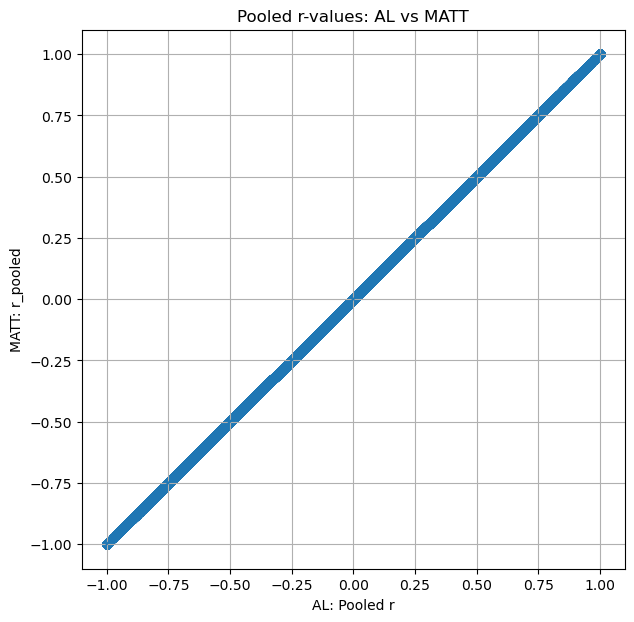

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Read input files
al = pd.read_csv("ananya_lauren_values.csv")
al.iloc[:, 0] = al.iloc[:, 0].str[:-2]   # remove "-P"

matt = pd.read_csv("new_matt_values.csv")

# Cleaning function
def clean(col):
    return (col.astype(str).str.strip().str.replace(r'\s+', ' ', regex=True))

# Clean text columns
al['Gene'] = clean(al['Gene'])
al['Metabolite'] = clean(al['Metabolite'])
matt['n1'] = clean(matt['n1'])
matt['n2'] = clean(matt['n2'])

# Create matching pairs
al['pair'] = list(zip(al['Gene'], al['Metabolite']))
matt['pair'] = list(zip(matt['n1'], matt['n2']))

# Merge on pair
merged = al.merge(
    matt,
    on='pair',
    suffixes=('_al', '_matt')
)

# Extract r values
x = merged['Pooled r']        # AL values
y = merged['r_pooled']        # MATT values

# =========================
#   SCATTERPLOT
# =========================
plt.figure(figsize=(7,7))
plt.scatter(x, y)
plt.xlabel("AL: Pooled r")
plt.ylabel("MATT: r_pooled")
plt.title("Pooled r-values: AL vs MATT")
plt.grid(True)

# 1:1 reference diagonal
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

In [4]:
import pandas as pd
import numpy as np

# Read input files
al = pd.read_csv("ananya_lauren_values.csv")
al.iloc[:, 0] = al.iloc[:, 0].str[:-2]   # remove "-P"

matt = pd.read_csv("new_matt_values.csv")

# Cleaning function
def clean(col):
    return (col.astype(str).str.strip().str.replace(r'\s+', ' ', regex=True))

# Clean text columns
al['Gene'] = clean(al['Gene'])
al['Metabolite'] = clean(al['Metabolite'])
matt['n1'] = clean(matt['n1'])
matt['n2'] = clean(matt['n2'])

# Create matching pairs
al['pair'] = list(zip(al['Gene'], al['Metabolite']))
matt['pair'] = list(zip(matt['n1'], matt['n2']))

# Merge on pair
merged = al.merge(
    matt,
    on='pair',
    suffixes=('_al', '_matt')
)

# ===== Choose which values you want to compare =====
# POOLED r VALUES
# x = merged['Pooled r']      # AL values
# y = merged['r_pooled']      # MATT values

# VECPAC r values
# x = merged['VECPAC r']      # AL values
# y = merged['r_v']           # MATT values

# LPS r values
# x = merged['LPS r']         # AL values
# y = merged['r_l']           # MATT values

# DSS r values (current choice)
x = merged['DSS r']           # AL values
y = merged['r_d']             # MATT values

# POOLED p values
# x = merged['Pooled p']      # AL values
# y = merged['p_pooled']      # MATT values

# Convert to numeric just in case
x_num = pd.to_numeric(x, errors='coerce')
y_num = pd.to_numeric(y, errors='coerce')

# ===== Build output for ALL pairs =====
out_df = pd.DataFrame({
    'Metabolite': merged['Metabolite'],
    'Gene': merged['Gene'],
    'Matt': y_num,   # MATT's value
    'AL': x_num      # AL's value
})

# Write to CSV
out_df.to_csv("new.csv", index=False)

print("Wrote", len(out_df), "rows to new.csv")


Wrote 480194 rows to new.csv


In [6]:
import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt   # No longer needed

# Read input files
al = pd.read_csv("ananya_lauren_values.csv")
al.iloc[:, 0] = al.iloc[:, 0].str[:-2]   # remove "-P"

matt = pd.read_csv("new_matt_values.csv")

# Cleaning function
def clean(col):
    return (col.astype(str).str.strip().str.replace(r'\s+', ' ', regex=True))

# Clean text columns
al['Gene'] = clean(al['Gene'])
al['Metabolite'] = clean(al['Metabolite'])
matt['n1'] = clean(matt['n1'])
matt['n2'] = clean(matt['n2'])

# Create matching pairs
al['pair'] = list(zip(al['Gene'], al['Metabolite']))
matt['pair'] = list(zip(matt['n1'], matt['n2']))

# Merge on pair
merged = al.merge(
    matt,
    on='pair',
    suffixes=('_al', '_matt')
)

# POOLED r VALUES
#x = merged['Pooled r']      # AL values
#y = merged['r_pooled']      # MATT values
# VECPAC r values
#x = merged['VECPAC r']      # AL values
#y = merged['r_v']      # MATT values
# LPS r values
#x = merged['LPS r']      # AL values
#y = merged['r_l']      # MATT values
# DSS r values
x = merged['DSS r']      # AL values
y = merged['r_d']      # MATT values
# POOLED p values
#x = merged['Pooled p']      # AL values
#y = merged['p_pooled']      # MATT values


# =========================
#   FIND NON-MATCHING r's
# =========================

# Convert to numeric (in case there are strings)
x_num = pd.to_numeric(x, errors='coerce')
y_num = pd.to_numeric(y, errors='coerce')


# Define a tolerance for "matching" (change if you want stricter)
tol = 1e-6
#tol = 0

# Boolean mask where values don't match (and both are not NaN)
# Detect mismatches including NaN differences
mask = (
    (x_num.isna() & y_num.notna()) |      # AL missing, MATT present
    (x_num.notna() & y_num.isna()) |      # MATT missing, AL present
    (x_num.notna() & y_num.notna() & (np.abs(x_num - y_num) > tol))   # both present but different
)

# Subset of only mismatched rows
mismatches = merged.loc[mask, :].copy()

# If you want to see just Gene, Metabolite, and the two r-values:
mismatches_display = mismatches[[
    'Gene', 'Metabolite', 'DSS r', 'r_d'
]]

print("Number of mismatched Gene–Metabolite pairs:", len(mismatches_display))
print(mismatches_display)


Number of mismatched Gene–Metabolite pairs: 2760
                      Gene                                         Metabolite  \
16744   ENSMUSG00000069727  (2S,3R)-3-[(4E,7E)-Nona-4,7-dienoyl]-N,N-bis(t...   
16746   ENSMUSG00000069727  (7a-Isopropenyl-4,5-dimethyloctahydroinden-4-y...   
16749   ENSMUSG00000069727                      (pm)-alpha-Tocopherol acetate   
16753   ENSMUSG00000069727                 (R*,S*)-2,3-Dihydroxybutanoic acid   
16756   ENSMUSG00000069727               1-(2,4-Dimethoxyphenyl)-propan-2-one   
...                    ...                                                ...   
480016  ENSMUSG00000038135                                       L-Asparagine   
480048  ENSMUSG00000038135                       Methyl 2,4-dihydroxybenzoate   
480139  ENSMUSG00000038135                                        Propylamine   
480157  ENSMUSG00000038135                   Sertraline carbamoyl glucuronide   
480178  ENSMUSG00000038135  Trimethylsilyl 3-((trimethylsily

In [8]:
import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt   # No longer needed

# Read input files
al = pd.read_csv("ananya_lauren_values.csv")
al.iloc[:, 0] = al.iloc[:, 0].str[:-2]   # remove "-P"

matt = pd.read_csv("new_matt_values.csv")

# Cleaning function
def clean(col):
    return (col.astype(str).str.strip().str.replace(r'\s+', ' ', regex=True))

# Clean text columns
al['Gene'] = clean(al['Gene'])
al['Metabolite'] = clean(al['Metabolite'])
matt['n1'] = clean(matt['n1'])
matt['n2'] = clean(matt['n2'])

# Create matching pairs
al['pair'] = list(zip(al['Gene'], al['Metabolite']))
matt['pair'] = list(zip(matt['n1'], matt['n2']))

# Merge on pair
merged = al.merge(
    matt,
    on='pair',
    suffixes=('_al', '_matt')
)

# Consistency
x = merged['consistent']      # AL values
y = merged['Consistent']      # MATT values

# Convert to lower-case strings to avoid True/TRUE mismatch etc.
x_str = x.astype(str).str.strip().str.lower()
y_str = y.astype(str).str.strip().str.lower()

# Mask for mismatches
mask = (x_str != y_str)

# Subset mismatches
mismatches = merged.loc[mask, :].copy()

# Display key columns (change as needed)
mismatches_display = mismatches[[
    'Gene', 'Metabolite', 'consistent', 'Consistent'
]]

print("Number of mismatched Gene–Metabolite pairs:", len(mismatches_display))
print(mismatches_display)


Number of mismatched Gene–Metabolite pairs: 52771
                      Gene                                 Metabolite  \
9       ENSMUSG00000027374         (R*,S*)-2,3-Dihydroxybutanoic acid   
10      ENSMUSG00000027374                     (S,S)-(-)-Hydrobenzoin   
21      ENSMUSG00000027374                        1-Decene, 8-methyl-   
22      ENSMUSG00000027374                            1-Deoxypentitol   
25      ENSMUSG00000027374  1-Hydroxy-3-methoxy-6-methylanthraquinone   
...                    ...                                        ...   
480164  ENSMUSG00000038135                         Succinic anhydride   
480167  ENSMUSG00000038135                 Tacrine, N-trimethylsilyl-   
480183  ENSMUSG00000038135                                 L-Tyrosine   
480188  ENSMUSG00000038135                               Valylglycine   
480191  ENSMUSG00000038135                                    Xylitol   

        consistent  Consistent  
9             True       False  
10     

In [10]:
import os
import pandas as pd
import numpy as np

# =========================
# Settings
# =========================
DIFF_DIR = "differing"
RTOL = 1e-5
ATOL = 1e-8

# Read input files
al = pd.read_csv("ananya_lauren_values.csv")
al.iloc[:, 0] = al.iloc[:, 0].astype(str).str[:-2]   # remove "-P" safely

matt = pd.read_csv("new_matt_values.csv")

# Cleaning function
def clean(col):
    return col.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

# Clean text columns
al["Gene"] = clean(al["Gene"])
al["Metabolite"] = clean(al["Metabolite"])
matt["n1"] = clean(matt["n1"])
matt["n2"] = clean(matt["n2"])

# Create matching pairs
al["pair"] = list(zip(al["Gene"], al["Metabolite"]))
matt["pair"] = list(zip(matt["n1"], matt["n2"]))

# Merge on pair
merged = al.merge(matt, on="pair", suffixes=("_al", "_matt"))

# =========================
# What to compare (AL col -> MATT col)
# =========================
comparisons = [
    ("Pooled r",  "r_pooled", "pooled_r"),
    ("VECPAC r",  "r_v",      "vecpac_r"),
    ("LPS r",     "r_l",      "lps_r"),
    ("DSS r",     "r_d",      "dss_r"),
    ("Pooled p",  "p_pooled", "pooled_p"),
]

# Create output folder
os.makedirs(DIFF_DIR, exist_ok=True)

# Helper: difference mask with NaN handling + tolerance
def differs(a, b, rtol=RTOL, atol=ATOL):
    # same if both NaN
    both_nan = a.isna() & b.isna()
    # close if numeric and within tolerance
    close = np.isclose(a, b, rtol=rtol, atol=atol, equal_nan=True)
    return ~(both_nan | close)

summary_rows = []

for al_col, matt_col, tag in comparisons:
    if al_col not in merged.columns or matt_col not in merged.columns:
        print(f"Skipping {tag}: missing column(s): {al_col=} {matt_col=}")
        continue

    a = pd.to_numeric(merged[al_col], errors="coerce")
    b = pd.to_numeric(merged[matt_col], errors="coerce")

    diff_mask = differs(a, b)

    diff_df = pd.DataFrame({
        "Metabolite": merged["Metabolite"],
        "Gene": merged["Gene"],
        "Matt": b,
        "AL": a,
        "Diff (Matt-AL)": (b - a),
        "Abs Diff": (b - a).abs(),
    })[diff_mask].copy()

    out_path = os.path.join(DIFF_DIR, f"{tag}_differing.csv")
    diff_df.to_csv(out_path, index=False)

    n_diff = int(diff_mask.sum())
    n_total = len(merged)

    if n_diff > 0:
        max_abs = float(diff_df["Abs Diff"].max(skipna=True))
        mean_abs = float(diff_df["Abs Diff"].mean(skipna=True))
    else:
        max_abs = 0.0
        mean_abs = 0.0

    print(f"{tag}: {n_diff} / {n_total} rows differ")
    if n_diff > 0:
        print(f"  max |diff| = {max_abs}")
        print(f"  mean |diff| = {mean_abs}")

    summary_rows.append({
        "metric": tag,
        "al_column": al_col,
        "matt_column": matt_col,
        "total_rows": n_total,
        "differing_rows": n_diff,
        "max_abs_diff": max_abs,
        "mean_abs_diff": mean_abs,
        "output_file": out_path,
    })

# Write a summary CSV
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(DIFF_DIR, "summary.csv"), index=False)

print(f"\nDone. Wrote per-metric differing CSVs + summary to: {DIFF_DIR}/")


pooled_r: 282 / 480194 rows differ
  max |diff| = nan
  mean |diff| = nan
vecpac_r: 707 / 480194 rows differ
  max |diff| = nan
  mean |diff| = nan
lps_r: 3462 / 480194 rows differ
  max |diff| = nan
  mean |diff| = nan
dss_r: 2760 / 480194 rows differ
  max |diff| = nan
  mean |diff| = nan
pooled_p: 282 / 480194 rows differ
  max |diff| = nan
  mean |diff| = nan

Done. Wrote per-metric differing CSVs + summary to: differing/


In [12]:
import os
import pandas as pd
import numpy as np

# =========================
# Settings
# =========================
DIFF_DIR = "differing"
RTOL = 1e-5
ATOL = 1e-8

# Read input files
al = pd.read_csv("ananya_lauren_values.csv")
al.iloc[:, 0] = al.iloc[:, 0].astype(str).str[:-2]   # remove "-P" safely

matt = pd.read_csv("new_matt_values.csv")

# Cleaning function
def clean(col):
    return col.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

# Clean text columns
al["Gene"] = clean(al["Gene"])
al["Metabolite"] = clean(al["Metabolite"])
matt["n1"] = clean(matt["n1"])
matt["n2"] = clean(matt["n2"])

# Create matching pairs
al["pair"] = list(zip(al["Gene"], al["Metabolite"]))
matt["pair"] = list(zip(matt["n1"], matt["n2"]))

# Merge on pair
merged = al.merge(matt, on="pair", suffixes=("_al", "_matt"))

# Validate consistency columns exist
if "Consistent" not in merged.columns:
    raise KeyError("Missing AL consistency column: 'Consistent' (from ananya_lauren_values.csv)")
if "consistent" not in merged.columns:
    raise KeyError("Missing Matt consistency column: 'consistent' (from new_matt_values.csv)")

# =========================
# What to compare (AL col -> MATT col)
# =========================
comparisons = [
    ("Pooled r",  "r_pooled", "pooled_r"),
    ("VECPAC r",  "r_v",      "vecpac_r"),
    ("LPS r",     "r_l",      "lps_r"),
    ("DSS r",     "r_d",      "dss_r"),
    ("Pooled p",  "p_pooled", "pooled_p"),
]

# Create output folder
os.makedirs(DIFF_DIR, exist_ok=True)

# Helper: difference mask with NaN handling + tolerance
def differs(a, b, rtol=RTOL, atol=ATOL):
    both_nan = a.isna() & b.isna()
    close = np.isclose(a, b, rtol=rtol, atol=atol, equal_nan=True)
    return ~(both_nan | close)

summary_rows = []

for al_col, matt_col, tag in comparisons:
    if al_col not in merged.columns or matt_col not in merged.columns:
        print(f"Skipping {tag}: missing column(s): {al_col=} {matt_col=}")
        continue

    a = pd.to_numeric(merged[al_col], errors="coerce")
    b = pd.to_numeric(merged[matt_col], errors="coerce")

    diff_mask = differs(a, b)

    # Consistency values (kept as-is; also include mismatch flag)
    al_cons = merged["Consistent"]
    matt_cons = merged["consistent"]
    cons_diff = ~(al_cons.fillna("__NA__").astype(str) == matt_cons.fillna("__NA__").astype(str))

    diff_df = pd.DataFrame({
        "Metabolite": merged["Metabolite"],
        "Gene": merged["Gene"],

        "AL Consistent": al_cons,
        "Matt consistent": matt_cons,
        "Consistent differs": cons_diff,

        "Matt": b,
        "AL": a,
        "Diff (Matt-AL)": (b - a),
        "Abs Diff": (b - a).abs(),
    })[diff_mask].copy()

    out_path = os.path.join(DIFF_DIR, f"{tag}_differing.csv")
    diff_df.to_csv(out_path, index=False)

    n_diff = int(diff_mask.sum())
    n_total = len(merged)

    if n_diff > 0:
        max_abs = float(diff_df["Abs Diff"].max(skipna=True))
        mean_abs = float(diff_df["Abs Diff"].mean(skipna=True))
        n_cons_diff_within = int(diff_df["Consistent differs"].sum())
    else:
        max_abs = 0.0
        mean_abs = 0.0
        n_cons_diff_within = 0

    print(f"{tag}: {n_diff} / {n_total} rows differ")
    if n_diff > 0:
        print(f"  max |diff| = {max_abs}")
        print(f"  mean |diff| = {mean_abs}")
        print(f"  (within differing rows) consistency differs in {n_cons_diff_within} rows")

    summary_rows.append({
        "metric": tag,
        "al_column": al_col,
        "matt_column": matt_col,
        "total_rows": n_total,
        "differing_rows": n_diff,
        "max_abs_diff": max_abs,
        "mean_abs_diff": mean_abs,
        "consistency_diff_within_differing_rows": n_cons_diff_within,
        "output_file": out_path,
    })

# Write a summary CSV
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(DIFF_DIR, "summary.csv"), index=False)

print(f"\nDone. Wrote per-metric differing CSVs + summary to: {DIFF_DIR}/")


pooled_r: 282 / 480194 rows differ
  max |diff| = nan
  mean |diff| = nan
  (within differing rows) consistency differs in 0 rows
vecpac_r: 707 / 480194 rows differ
  max |diff| = nan
  mean |diff| = nan
  (within differing rows) consistency differs in 0 rows
lps_r: 3462 / 480194 rows differ
  max |diff| = nan
  mean |diff| = nan
  (within differing rows) consistency differs in 0 rows
dss_r: 2760 / 480194 rows differ
  max |diff| = nan
  mean |diff| = nan
  (within differing rows) consistency differs in 0 rows
pooled_p: 282 / 480194 rows differ
  max |diff| = nan
  mean |diff| = nan
  (within differing rows) consistency differs in 0 rows

Done. Wrote per-metric differing CSVs + summary to: differing/
